# Competition Comparison

How do shooting profiles differ between competitions?

Focus: structural differences (shot positions, defensive pressure, play patterns)
NOT individual quality. Findings here motivate whether to add competition as a feature
or whether the model can be domain-agnostic.

Filter: only competitions with >= 1000 shots to avoid small-sample artifacts.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

df = pd.read_parquet(Path("../data/shots_features.parquet"))

MIN_SHOTS = 1000
comp_counts = df["competition"].value_counts()
big_comps = comp_counts[comp_counts >= MIN_SHOTS].index.tolist()
df_big = df[df["competition"].isin(big_comps)].copy()

print(f"Kept {len(big_comps)} competitions with >= {MIN_SHOTS} shots:")
for c in big_comps:
    print(f"  {c:<28} {comp_counts[c]:>6,} shots")
print(f"\nTotal shots in analysis: {len(df_big):,} / {len(df):,}")

Kept 9 competitions with >= 1000 shots:
  La Liga                      20,936 shots
  Premier League               10,735 shots
  Ligue 1                      10,235 shots
  Serie A                       9,912 shots
  FIFA World Cup                3,770 shots
  Indian Super league           3,053 shots
  UEFA Euro                     2,538 shots
  1. Bundesliga                 1,738 shots
  African Cup of Nations        1,162 shots

Total shots in analysis: 64,079 / 65,822


## 1. Headline Metrics: Shots/Match, Goal Rate, Avg xG

In [2]:
summary = df_big.groupby("competition").agg(
    matches=("match_id", "nunique"),
    shots=("is_goal", "count"),
    goals=("is_goal", "sum"),
    goal_rate=("is_goal", "mean"),
    avg_distance=("geom_distance", "mean"),
    avg_angle_deg=("geom_angle_deg", "mean"),
    avg_sb_xg=("statsbomb_xg", "mean"),
)
summary["shots_per_match"] = summary["shots"] / summary["matches"]
summary["goals_per_match"] = summary["goals"] / summary["matches"]
summary["finishing_vs_xg"] = summary["goal_rate"] - summary["avg_sb_xg"]
summary = summary.sort_values("goal_rate", ascending=False)

display_cols = ["matches", "shots", "shots_per_match", "goals_per_match",
                "goal_rate", "avg_sb_xg", "finishing_vs_xg",
                "avg_distance", "avg_angle_deg"]
print(summary[display_cols].round(3).to_string())

                        matches  shots  shots_per_match  goals_per_match  goal_rate  avg_sb_xg  finishing_vs_xg  avg_distance  avg_angle_deg
competition                                                                                                                                 
La Liga                     867  20936           24.148            2.840      0.118      0.103            0.014        19.198         24.857
1. Bundesliga                68   1738           25.559            2.706      0.106      0.102            0.004        18.337         25.788
Indian Super league         115   3053           26.548            2.739      0.103      0.089            0.014        20.098         24.450
Ligue 1                     435  10235           23.529            2.361      0.100      0.095            0.006        19.583         24.855
Premier League              418  10735           25.682            2.388      0.093      0.092            0.001        19.323         25.082
FIFA World Cu

## 2. Goal Rate vs Avg StatsBomb xG (over/under-performance by competition)

If goal_rate > avg_sb_xg => league finishes better than expected.
This is a model-free hint about finishing tendencies.

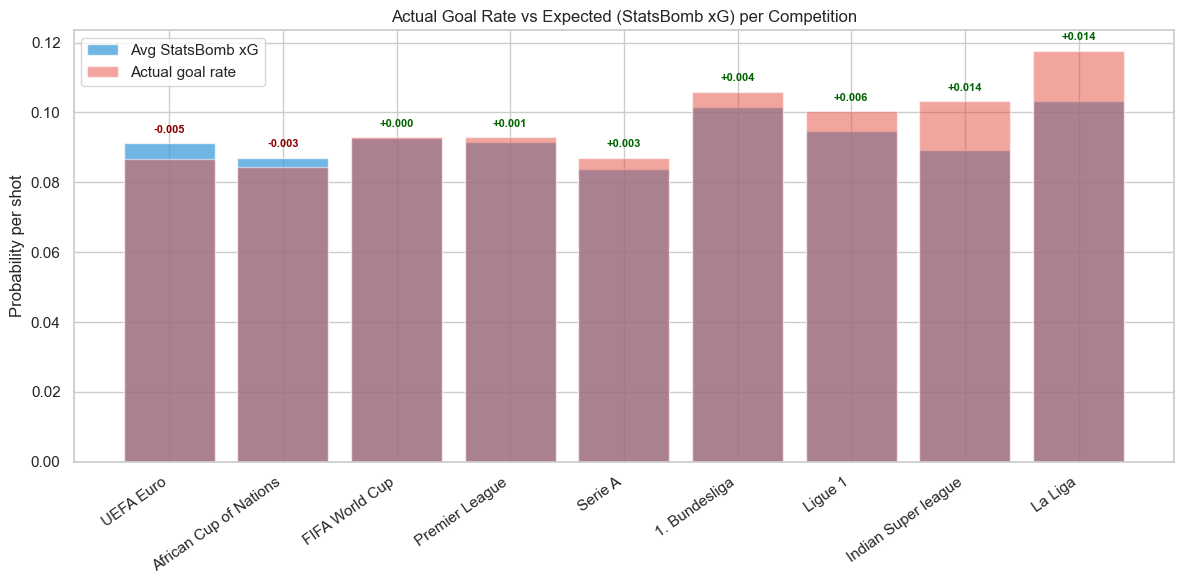

In [3]:
s = summary.sort_values("finishing_vs_xg")

fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(s))
ax.bar(x, s["avg_sb_xg"], color="#3498db", alpha=0.7, label="Avg StatsBomb xG")
ax.bar(x, s["goal_rate"], color="#e74c3c", alpha=0.5, label="Actual goal rate")
ax.set_xticks(x)
ax.set_xticklabels(s.index, rotation=35, ha="right")
ax.set_ylabel("Probability per shot")
ax.set_title("Actual Goal Rate vs Expected (StatsBomb xG) per Competition")
ax.legend()

for i, (rate, xg) in enumerate(zip(s["goal_rate"], s["avg_sb_xg"])):
    diff = rate - xg
    color = "darkgreen" if diff >= 0 else "darkred"
    ax.text(i, max(rate, xg) + 0.003,
            f"{diff:+.3f}", ha="center", color=color, fontsize=8, fontweight="bold")

plt.tight_layout()
plt.show()

## 3. Shot Distance Distributions per Competition

Do some leagues shoot from farther out? Could explain goal-rate differences.

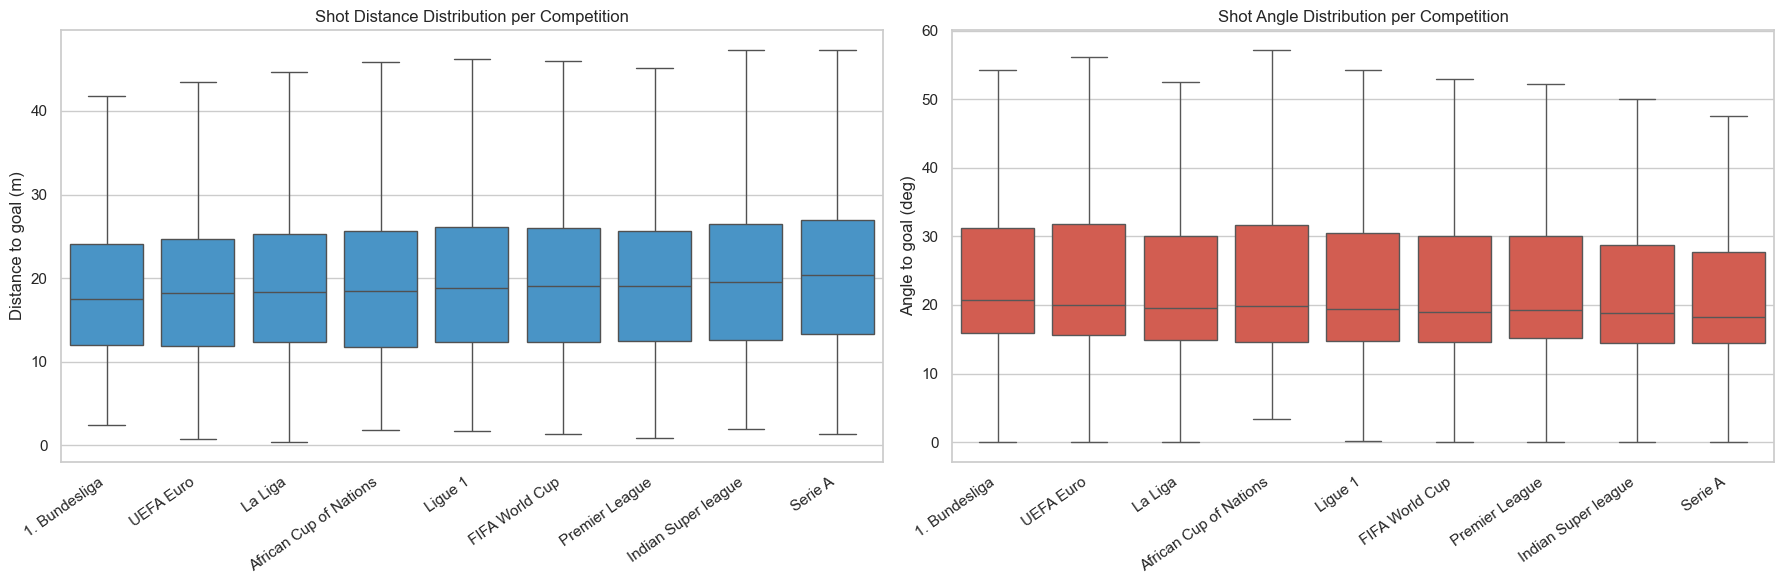

In [4]:
order = df_big.groupby("competition")["geom_distance"].median().sort_values().index

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.boxplot(data=df_big, x="competition", y="geom_distance", order=order,
            ax=axes[0], color="#3498db", showfliers=False)
axes[0].set_title("Shot Distance Distribution per Competition")
axes[0].set_ylabel("Distance to goal (m)")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=35)
for label in axes[0].get_xticklabels():
    label.set_horizontalalignment("right")

sns.boxplot(data=df_big, x="competition", y="geom_angle_deg", order=order,
            ax=axes[1], color="#e74c3c", showfliers=False)
axes[1].set_title("Shot Angle Distribution per Competition")
axes[1].set_ylabel("Angle to goal (deg)")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=35)
for label in axes[1].get_xticklabels():
    label.set_horizontalalignment("right")

plt.tight_layout()
plt.show()

## 4. Play Pattern & Shot Type Mix per Competition

Different leagues build attacks differently (more counter, more set pieces, etc).

Play pattern % per competition:

play_pattern            From Corner  From Counter  From Free Kick  From Goal Kick  From Keeper  From Kick Off  From Throw In  Other  Regular Play
competition                                                                                                                                      
1. Bundesliga                  18.3           5.1            21.2             4.4          2.0            0.7           16.7    0.1          31.4
UEFA Euro                      17.0           4.4            18.8             4.4          2.4            1.4           18.2    0.4          33.1
La Liga                        15.2           4.4            23.0             3.7          1.4            1.2           16.5    0.1          34.4
African Cup of Nations         15.8           4.6            24.2             4.6          2.2            1.8           19.1    0.0          27.6
Ligue 1                        15.5           4.9            21.3             4.0          

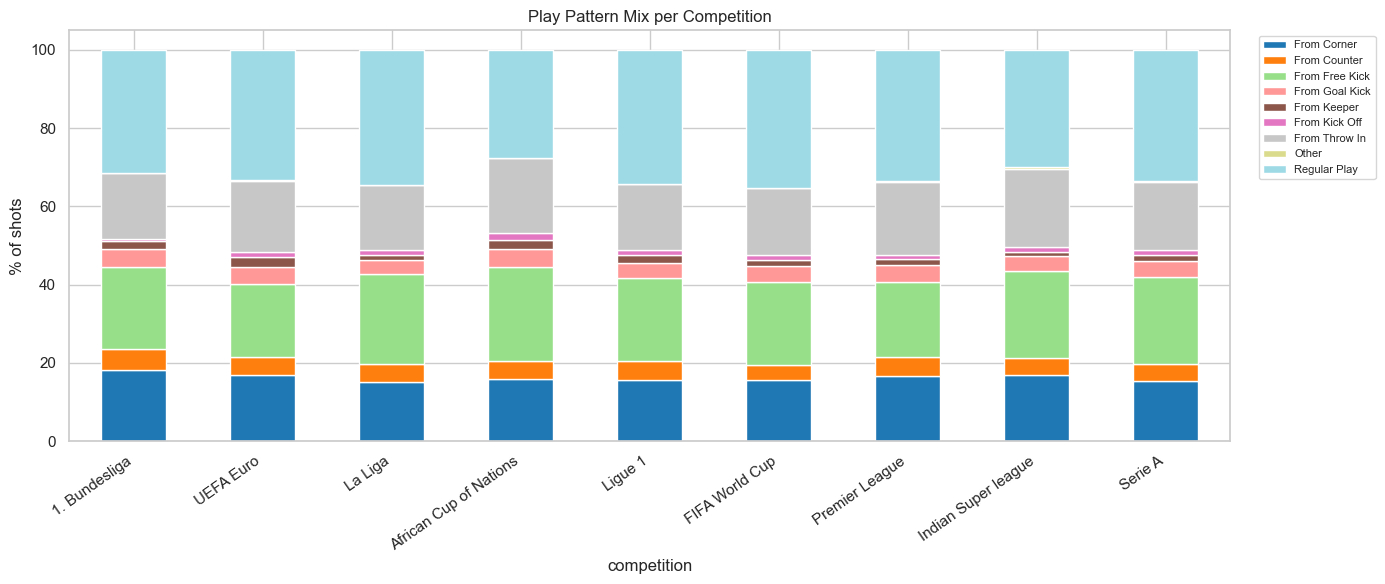

In [5]:
pp = pd.crosstab(df_big["competition"], df_big["play_pattern"], normalize="index") * 100
pp = pp.loc[order]
print("Play pattern % per competition:\n")
print(pp.round(1).to_string())

fig, ax = plt.subplots(figsize=(14, 6))
pp.plot(kind="bar", stacked=True, ax=ax, colormap="tab20")
ax.set_ylabel("% of shots")
ax.set_title("Play Pattern Mix per Competition")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

## 5. Defensive Pressure & Freeze-Frame Metrics

How crowded is the shot cone in each league? More defenders => harder shots on avg.

                        avg_def_in_cone  avg_dist_nearest_def  avg_gk_off_line  pct_under_pressure
competition                                                                                       
1. Bundesliga                     1.769                 3.041            2.482              27.618
UEFA Euro                         1.792                 2.862            2.365              27.266
La Liga                           1.676                 3.077            2.512              17.955
African Cup of Nations            1.808                 3.059            2.408              30.637
Ligue 1                           1.731                 3.053            2.830              28.803
FIFA World Cup                    1.782                 3.239            2.057              19.973
Premier League                    1.787                 2.983            2.620              21.574
Indian Super league               1.827                 3.161            2.365              17.229
Serie A   

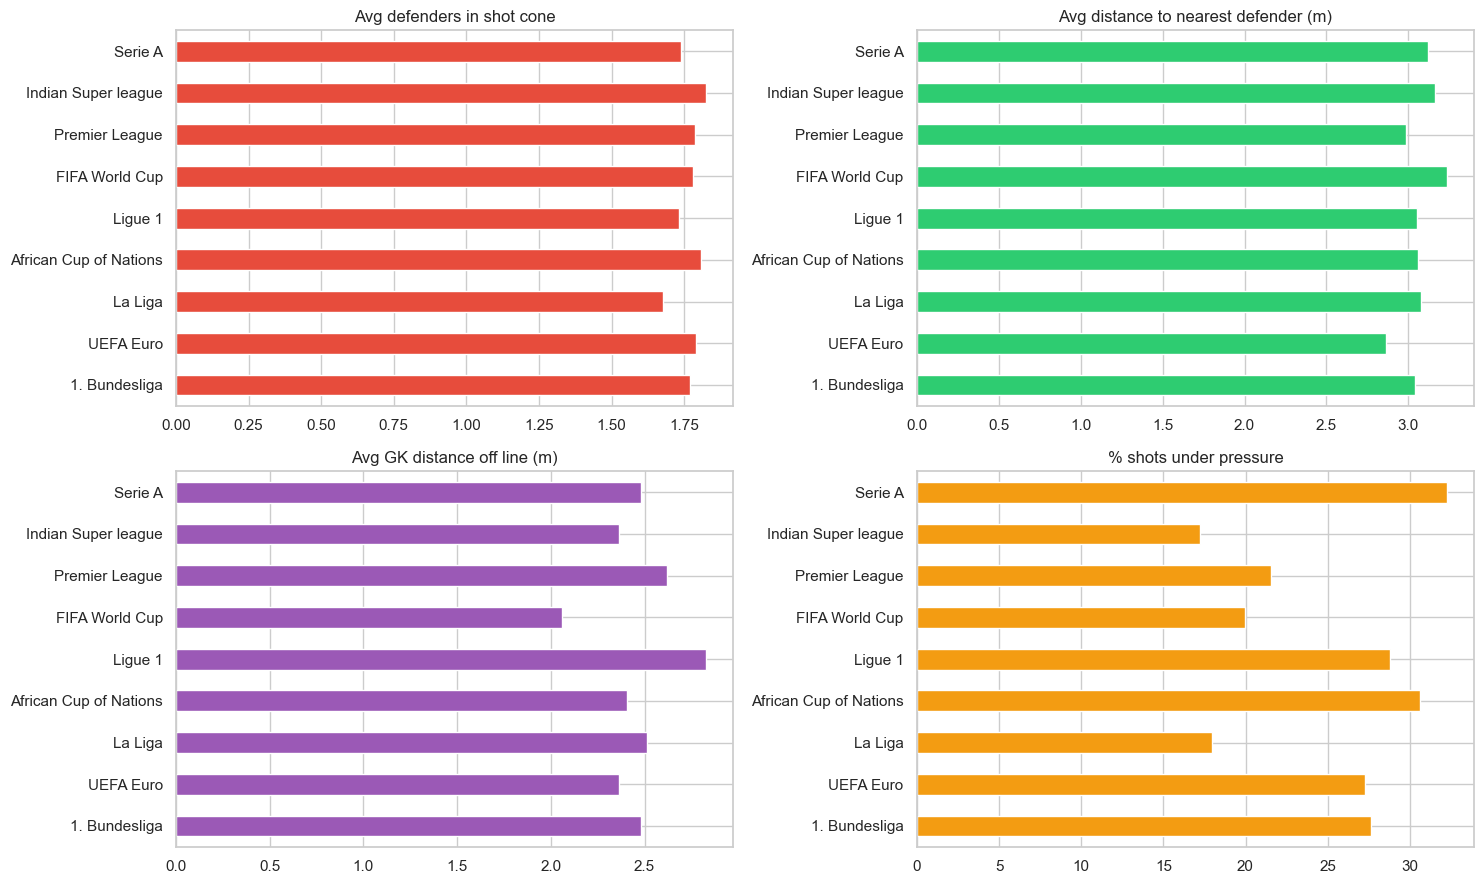

In [6]:
pressure_stats = df_big.groupby("competition").agg(
    avg_def_in_cone=("ff_n_opponents_in_cone", "mean"),
    avg_dist_nearest_def=("ff_dist_nearest_opponent", "mean"),
    avg_gk_off_line=("ff_gk_off_line", "mean"),
    pct_under_pressure=("under_pressure", "mean"),
)
pressure_stats["pct_under_pressure"] *= 100
pressure_stats = pressure_stats.loc[order].round(3)
print(pressure_stats.to_string())

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
for ax, col, title, color in zip(
    axes.flatten(),
    ["avg_def_in_cone", "avg_dist_nearest_def", "avg_gk_off_line", "pct_under_pressure"],
    ["Avg defenders in shot cone",
     "Avg distance to nearest defender (m)",
     "Avg GK distance off line (m)",
     "% shots under pressure"],
    ["#e74c3c", "#2ecc71", "#9b59b6", "#f39c12"],
):
    pressure_stats[col].plot(kind="barh", ax=ax, color=color)
    ax.set_title(title)
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

## 6. Summary -- Modeling Implication

Key question: are between-league differences in goal rate explained by
shot-quality differences (distance, defenders, etc.) or by finishing skill?

If shot-quality features absorb most of the variance, we DON'T need to add
"competition" as a feature in the model. If big residual differences remain
after controlling for shot quality, then competition may have predictive value.

This is exactly what the Phase 4 model + calibration check will answer.